<a href="https://colab.research.google.com/github/Riya-87/regression-project/blob/main/Copy_of_Copy_of_Sample_ML_Submission_Template.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Name**    - NYC Taxi Trip Duration Prediction

##### **Project Type**    - Regression

# **Project Summary -**

*   **Objective:** Predict NYC taxi trip durations using machine learning to improve operational efficiency, pricing, and customer satisfaction.
*   **Data Overview:** Utilized a comprehensive dataset of over 1.4 million NYC taxi trips, featuring pickup/dropoff times, passenger counts, geographical coordinates, and `trip_duration` (target variable).
*   **Data Quality:** Dataset was clean with no missing or duplicate values.
*   **Data Preprocessing & Feature Engineering:**
    *   Dropped irrelevant columns (`id`, `vendor_id`, `dropoff_datetime`).
    *   Extracted temporal features (year, month, day, hour, minute, second) from `pickup_datetime`.
    *   One-hot encoded `store_and_fwd_flag`.
    *   Transformed `trip_duration` from seconds to minutes for better interpretability.
*   **Exploratory Data Analysis (EDA):**
    *   Histograms revealed a heavily right-skewed `trip_duration` distribution (many short trips, few very long ones).
    *   Most trips involved 1-2 passengers.
    *   Box plots showed `trip_duration` outliers across all `passenger_count`s.
    *   Line plots identified distinct diurnal patterns in average trip duration, with peaks during rush hours.
*   **Model Implementation:**
    *   **Linear Regression:** Served as a baseline, showing limited capture of complex patterns.
    *   **Random Forest Regressor:** Demonstrated significantly better performance than Linear Regression in training, but a negative test R2 score indicated potential overfitting or issues with outlier handling and scaling strategy.
*   **Business Impact:** Insights and models support dynamic pricing, optimized driver allocation, improved ETA accuracy, and overall operational efficiency.
*   **Next Steps:** Focus on robust outlier treatment, hyperparameter tuning (e.g., using `RandomizedSearchCV`), and exploring advanced models (e.g., XGBoost) to further enhance predictive accuracy and business utility.

This project focuses on predicting taxi trip durations in New York City using a comprehensive dataset that includes various features related to trip logistics and environmental factors. The primary goal is to develop a machine learning model that can accurately estimate the `trip_duration`, which has significant implications for operational efficiency, dynamic pricing strategies, and customer satisfaction in the ride-hailing industry.

**Data Loading and Initial Exploration:**

The project began by loading the NYC Taxi Data into a pandas DataFrame. Initial steps involved inspecting the dataset's structure using `df.head()`, `df.shape`, and `df.info()`. This revealed that the dataset contains over 1.4 million entries and 11 columns, including trip identifiers, vendor information, pickup and dropoff timestamps, passenger counts, geographical coordinates (longitude and latitude), a store-and-forward flag, and the target variable, `trip_duration`. Crucially, there were no missing values identified in the dataset, which simplifies the data cleaning process.

**Data Wrangling and Feature Engineering:**

To prepare the data for modeling, several data wrangling and feature engineering steps were performed:

1.  **Column Dropping:** Irrelevant columns such as `id`, `vendor_id`, and `dropoff_datetime` were dropped. `id` and `vendor_id` were considered non-informative for predicting trip duration, and `dropoff_datetime` was directly related to the target `trip_duration` (its difference from `pickup_datetime`), making it redundant as a direct feature.
2.  **Datetime Feature Extraction:** The `pickup_datetime` column, initially an object type, was converted into a datetime object. This allowed for the extraction of granular temporal features like `pickup_year`, `pickup_month`, `pickup_day`, `pickup_hour`, `pickup_minute`, and `pickup_second`. These features are vital for capturing temporal patterns and seasonality in trip durations.
3.  **Categorical Encoding:** The `store_and_fwd_flag` column, a categorical variable indicating whether the trip data was held in the vehicle's memory before sending to the vendor, was one-hot encoded. Specifically, `pd.get_dummies` was used, and `drop_first=True` was applied to avoid multicollinearity, resulting in a `store_and_fwd_flag_Y` boolean column.
4.  **Target Variable Transformation:** The `trip_duration` was originally in seconds. For potentially better model interpretability and to align with common human understanding of trip length, it was converted to minutes by integer division (`//60`). This transformation might also help in handling extreme outliers in duration more gracefully.

**Exploratory Data Analysis (EDA):**

Key visualizations were generated to understand the data distribution and relationships:

*   **Histograms:** Histograms of all numerical features (`df.hist()`) provided a quick overview of their distributions. For example, `trip_duration` showed a heavily skewed distribution, indicative of many short trips and a few very long ones.
*   **Box Plots:** A box plot of `trip_duration` by `passenger_count` revealed that while median trip durations were similar across different passenger counts, there were significant outliers, especially for higher passenger counts, suggesting that very few passengers might take exceptionally long trips.
*   **Line Plot:** A line plot of `Average Trip Duration by Hour of Day` highlighted diurnal patterns, with longer average trip durations often occurring during peak hours and shorter durations during off-peak times. This insight is critical for understanding demand-supply dynamics and traffic congestion.
*   **Scatter Plot:** A scatter plot of `pickup_longitude` vs. `pickup_latitude` helped visualize the geographical distribution of pickups, clearly showing high-density areas (e.g., Manhattan) and lower activity zones, which can inform driver deployment strategies.

**Model Implementation - Linear Regression:**

The initial machine learning model implemented was a Linear Regression. The dataset was split into training and testing sets (80/20 split). Feature scaling was applied using `MinMaxScaler` on the input features (`x_train` and `x_test`) to normalize their ranges, which is beneficial for gradient-descent-based models and can prevent features with larger scales from dominating the learning process. The Linear Regression model was then fitted to the scaled training data. Evaluation metrics such as R2 score, Mean Absolute Percentage Error (MAPE), Mean Squared Error (MSE), and Mean Absolute Error (MAE) were calculated for both training and test sets to assess the model's performance.

**Model Implementation - Random Forest Regressor:**

Following the Linear Regression, a Random Forest Regressor was introduced. This ensemble model is generally more robust and capable of capturing non-linear relationships compared to simple linear models. The `RandomForestRegressor` was initialized with 100 estimators (`n_estimators=100`) and trained on the same scaled data. Predictions were made on both training and test sets, and the R2 score, MAPE, MSE, and MAE were computed. The expectation is that the Random Forest model will demonstrate improved accuracy and generalization capabilities due to its ensemble nature and ability to handle complex feature interactions.

**Next Steps:**

Further steps would involve hyperparameter tuning for the Random Forest model using techniques like GridSearchCV or RandomizedSearchCV to optimize its performance, given the dataset's size. Additionally, detailed analysis of feature importance could provide insights into which features contribute most significantly to `trip_duration` prediction. This comprehensive approach ensures a robust and insightful analysis of taxi trip dynamics.

# **GitHub Link -**

https://github.com/Riya-87/regression-project

# **Problem Statement**


The increasing demand for efficient and reliable taxi services in urban environments, such as New York City, necessitates accurate prediction of trip durations. Inaccurate trip duration estimates can lead to several business challenges:

1.  **Suboptimal Resource Allocation:** Taxi companies struggle to effectively deploy drivers, resulting in increased idle time or missed opportunities during peak demand, impacting overall fleet efficiency and driver earnings.
2.  **Customer Dissatisfaction:** Passengers receive unreliable estimated times of arrival (ETAs) and fare estimates, leading to frustration, negative experiences, and potential loss of customer loyalty.
3.  **Inefficient Pricing Strategies:** Dynamic pricing models are hampered by poor trip duration predictions, leading to either underpricing (revenue loss) or overpricing (customer deterrent).
4.  **Operational Bottlenecks:** Lack of foresight into trip lengths can cause traffic congestion, scheduling conflicts, and difficulties in managing consecutive rides.

**Problem Statement:**

Develop a robust machine learning model that can accurately predict the `trip_duration` for taxi rides in New York City. The model should leverage various trip-related features, including temporal data (e.g., time of day, day of week), geographical coordinates (pickup and dropoff locations), passenger count, and other relevant contextual information. The goal is to minimize prediction errors, thereby enabling improved operational efficiency, enhanced customer satisfaction, and optimized pricing strategies for taxi service providers.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [6]:
# Import Libraries
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression,Lasso,Ridge
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error,mean_absolute_percentage_error
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler,MinMaxScaler,RobustScaler

In [ ]:
from tabulate import tabulate

def plot_metric_scores(model_name, train_r2, train_mape, train_mse, train_mae, test_r2, test_mape, test_mse, test_mae):
    metrics = [
        ["R2 Score", f"{train_r2:.4f}", f"{test_r2:.4f}"],
        ["MAPE", f"{train_mape:.2f} %", f"{test_mape:.2f} %"],
        ["MSE", f"{train_mse:.2f}", f"{test_mse:.2f}"],
        ["MAE", f"{train_mae:.2f}", f"{test_mae:.2f}"]
    ]

    headers = ["Metric", "Train Score", "Test Score"]

    print(f"\nEvaluation Metrics for {model_name}:")
    print(tabulate(metrics, headers=headers, tablefmt="grid"))

    # Plotting
    labels = ['R2 Score', 'MAPE', 'MSE', 'MAE']
    train_scores = [train_r2, train_mape, train_mse, train_mae]
    test_scores = [test_r2, test_mape, test_mse, test_mae]

    x = np.arange(len(labels))
    width = 0.35

    fig, ax = plt.subplots(figsize=(10, 6))
    rects1 = ax.bar(x - width/2, train_scores, width, label='Train')
    rects2 = ax.bar(x + width/2, test_scores, width, label='Test')

    ax.set_ylabel('Score/Value')
    ax.set_title(f'Evaluation Metrics for {model_name}')
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.legend()

    fig.tight_layout()
    plt.show()

### Dataset Loading

In [7]:
# Load Dataset
df=pd.read_csv('/content/drive/MyDrive/Copy of NYC Taxi Data.csv')

### Dataset First View

In [8]:
# Dataset First Look
df.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435


### Dataset Rows & Columns count

In [9]:
# Dataset Rows & Columns count
df.shape

(1458644, 11)

### Dataset Information

In [10]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1458644 entries, 0 to 1458643
Data columns (total 11 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   id                  1458644 non-null  object 
 1   vendor_id           1458644 non-null  int64  
 2   pickup_datetime     1458644 non-null  object 
 3   dropoff_datetime    1458644 non-null  object 
 4   passenger_count     1458644 non-null  int64  
 5   pickup_longitude    1458644 non-null  float64
 6   pickup_latitude     1458644 non-null  float64
 7   dropoff_longitude   1458644 non-null  float64
 8   dropoff_latitude    1458644 non-null  float64
 9   store_and_fwd_flag  1458644 non-null  object 
 10  trip_duration       1458644 non-null  int64  
dtypes: float64(4), int64(3), object(4)
memory usage: 122.4+ MB


#### Duplicate Values

In [11]:
# Dataset Duplicate Value Count
df.duplicated().sum()

np.int64(0)

#### Missing Values/Null Values

In [12]:
# Missing Values/Null Values Count
df.isnull().sum()

,0
id,0
vendor_id,0
pickup_datetime,0
dropoff_datetime,0
passenger_count,0
pickup_longitude,0
pickup_latitude,0
dropoff_longitude,0
dropoff_latitude,0
store_and_fwd_flag,0


In [13]:
# Visualizing the missing values
# sns.heatmap(df.isnull(),cbar=False)

### What did you know about your dataset?

Answer Here.

From the initial data loading and inspection using `df.head()`, `df.shape`, and `df.info()`, we've gathered the following insights about the dataset:

*   **Size:** The dataset contains `1,458,644` entries (rows) and `11` columns.
*   **Columns:** The columns include `id`, `vendor_id`, `pickup_datetime`, `dropoff_datetime`, `passenger_count`, `pickup_longitude`, `pickup_latitude`, `dropoff_longitude`, `dropoff_latitude`, `store_and_fwd_flag`, and `trip_duration`.
*   **Data Types:**
    *   `float64`: `pickup_longitude`, `pickup_latitude`, `dropoff_longitude`, `dropoff_latitude`
    *   `int64`: `vendor_id`, `passenger_count`, `trip_duration`
    *   `object`: `id`, `pickup_datetime`, `dropoff_datetime`, `store_and_fwd_flag`
*   **Missing Values:** There are **no missing values** (`Non-Null Count` matches the total number of entries for all columns, and `df.isnull().sum()` confirms all zeros).
*   **Duplicate Values:** There are **no duplicate rows** in the dataset (`df.duplicated().sum()` returns 0).
*   **Memory Usage:** The dataset occupies approximately 122.4+ MB of memory.

## ***2. Understanding Your Variables***

In [14]:
# Dataset Columns
df.columns

Index(['id', 'vendor_id', 'pickup_datetime', 'dropoff_datetime',
       'passenger_count', 'pickup_longitude', 'pickup_latitude',
       'dropoff_longitude', 'dropoff_latitude', 'store_and_fwd_flag',
       'trip_duration'],
      dtype='object')

In [15]:
# Dataset Describe
df.describe()

,vendor_id,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,trip_duration
count,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06
mean,1.534950e+00,1.664530e+00,-7.397349e+01,4.075092e+01,-7.397342e+01,4.075180e+01,9.594923e+02
std,4.987772e-01,1.314242e+00,7.090186e-02,3.288119e-02,7.064327e-02,3.589056e-02,5.237432e+03
min,1.000000e+00,0.000000e+00,-1.219333e+02,3.435970e+01,-1.219333e+02,3.218114e+01,1.000000e+00
25%,1.000000e+00,1.000000e+00,-7.399187e+01,4.073735e+01,-7.399133e+01,4.073588e+01,3.970000e+02
50%,2.000000e+00,1.000000e+00,-7.398174e+01,4.075410e+01,-7.397975e+01,4.075452e+01,6.620000e+02
75%,2.000000e+00,2.000000e+00,-7.396733e+01,4.076836e+01,-7.396301e+01,4.076981e+01,1.075000e+03
max,2.000000e+00,9.000000e+00,-6.133553e+01,5.188108e+01,-6.133553e+01,4.392103e+01,3.526282e+06


### Variables Description

The dataset contains the following variables:

*   **`id`** (object): A unique identifier for each trip. This is a nominal categorical variable.
*   **`vendor_id`** (int64): An identifier indicating which of the two taxi vendors (1 or 2) provided the trip. This is a nominal categorical variable, treated as numerical.
*   **`pickup_datetime`** (object, then datetime): The date and time when the trip started. Initially an object, it has been converted to a datetime object for feature extraction.
*   **`dropoff_datetime`** (object): The date and time when the trip ended. This was dropped during data wrangling as it is directly related to the target variable.
*   **`passenger_count`** (int64): The number of passengers in the trip. This is a discrete numerical variable.
*   **`pickup_longitude`** (float64): The longitude coordinate of the pickup location. This is a continuous numerical variable.
*   **`pickup_latitude`** (float64): The latitude coordinate of the pickup location. This is a continuous numerical variable.
*   **`dropoff_longitude`** (float64): The longitude coordinate of the dropoff location. This is a continuous numerical variable.
*   **`dropoff_latitude`** (float64): The latitude coordinate of the dropoff location. This is a continuous numerical variable.
*   **`store_and_fwd_flag`** (object, then bool): A flag indicating whether the trip data was held in the vehicle's memory before sending to the vendor. 'Y' indicates stored, 'N' indicates not stored. This was one-hot encoded into `store_and_fwd_flag_Y` (boolean).
*   **`trip_duration`** (int64, then float64): The duration of the trip in seconds. This is the target variable for prediction. During data wrangling, it was converted to minutes (`trip_duration //= 60`).
*   **`pickup_year`** (int32): The year of the trip's pickup.
*   **`pickup_month`** (int32): The month of the trip's pickup.
*   **`pickup_day`** (int32): The day of the month of the trip's pickup.
*   **`pickup_hour`** (int32): The hour of the day of the trip's pickup.
*   **`pickup_minute`** (int32): The minute of the hour of the trip's pickup.
*   **`pickup_second`** (int32): The second of the minute of the trip's pickup.

These newly engineered temporal features provide more granular information for the models to learn from, potentially capturing daily and monthly patterns in trip durations.

### Check Unique Values for each variable.

In [16]:
# Check Unique Values for each variable.
df.nunique()

,0
id,1458644
vendor_id,2
pickup_datetime,1380222
dropoff_datetime,1380377
passenger_count,10
pickup_longitude,23047
pickup_latitude,45245
dropoff_longitude,33821
dropoff_latitude,62519
store_and_fwd_flag,2


## 3. ***Data Wrangling***

### Data Wrangling Code

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1458644 entries, 0 to 1458643
Data columns (total 11 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   id                  1458644 non-null  object 
 1   vendor_id           1458644 non-null  int64  
 2   pickup_datetime     1458644 non-null  object 
 3   dropoff_datetime    1458644 non-null  object 
 4   passenger_count     1458644 non-null  int64  
 5   pickup_longitude    1458644 non-null  float64
 6   pickup_latitude     1458644 non-null  float64
 7   dropoff_longitude   1458644 non-null  float64
 8   dropoff_latitude    1458644 non-null  float64
 9   store_and_fwd_flag  1458644 non-null  object 
 10  trip_duration       1458644 non-null  int64  
dtypes: float64(4), int64(3), object(4)
memory usage: 122.4+ MB


In [18]:
# Write your code to make your dataset analysis ready.
df.drop(['id','vendor_id','dropoff_datetime'],axis=1,inplace=True)

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1458644 entries, 0 to 1458643
Data columns (total 8 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   pickup_datetime     1458644 non-null  object 
 1   passenger_count     1458644 non-null  int64  
 2   pickup_longitude    1458644 non-null  float64
 3   pickup_latitude     1458644 non-null  float64
 4   dropoff_longitude   1458644 non-null  float64
 5   dropoff_latitude    1458644 non-null  float64
 6   store_and_fwd_flag  1458644 non-null  object 
 7   trip_duration       1458644 non-null  int64  
dtypes: float64(4), int64(2), object(2)
memory usage: 89.0+ MB


In [20]:
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])


# Pickup datetime features
df['pickup_year'] = df['pickup_datetime'].dt.year
df['pickup_month'] = df['pickup_datetime'].dt.month
df['pickup_day'] = df['pickup_datetime'].dt.day
df['pickup_hour'] = df['pickup_datetime'].dt.hour
df['pickup_minute'] = df['pickup_datetime'].dt.minute
df['pickup_second'] = df['pickup_datetime'].dt.second


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1458644 entries, 0 to 1458643
Data columns (total 14 columns):
 #   Column              Non-Null Count    Dtype         
---  ------              --------------    -----         
 0   pickup_datetime     1458644 non-null  datetime64[ns]
 1   passenger_count     1458644 non-null  int64         
 2   pickup_longitude    1458644 non-null  float64       
 3   pickup_latitude     1458644 non-null  float64       
 4   dropoff_longitude   1458644 non-null  float64       
 5   dropoff_latitude    1458644 non-null  float64       
 6   store_and_fwd_flag  1458644 non-null  object        
 7   trip_duration       1458644 non-null  int64         
 8   pickup_year         1458644 non-null  int32         
 9   pickup_month        1458644 non-null  int32         
 10  pickup_day          1458644 non-null  int32         
 11  pickup_hour         1458644 non-null  int32         
 12  pickup_minute       1458644 non-null  int32         
 13  pickup_secon

In [22]:
df['store_and_fwd_flag'].value_counts()

,count
store_and_fwd_flag,
N,1450599
Y,8045


In [23]:
df = pd.get_dummies(df, columns = ['store_and_fwd_flag'],drop_first = True)

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1458644 entries, 0 to 1458643
Data columns (total 14 columns):
 #   Column                Non-Null Count    Dtype         
---  ------                --------------    -----         
 0   pickup_datetime       1458644 non-null  datetime64[ns]
 1   passenger_count       1458644 non-null  int64         
 2   pickup_longitude      1458644 non-null  float64       
 3   pickup_latitude       1458644 non-null  float64       
 4   dropoff_longitude     1458644 non-null  float64       
 5   dropoff_latitude      1458644 non-null  float64       
 6   trip_duration         1458644 non-null  int64         
 7   pickup_year           1458644 non-null  int32         
 8   pickup_month          1458644 non-null  int32         
 9   pickup_day            1458644 non-null  int32         
 10  pickup_hour           1458644 non-null  int32         
 11  pickup_minute         1458644 non-null  int32         
 12  pickup_second         1458644 non-null  in

In [25]:
df.drop(['pickup_datetime'],axis=1,inplace=True)

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1458644 entries, 0 to 1458643
Data columns (total 13 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   passenger_count       1458644 non-null  int64  
 1   pickup_longitude      1458644 non-null  float64
 2   pickup_latitude       1458644 non-null  float64
 3   dropoff_longitude     1458644 non-null  float64
 4   dropoff_latitude      1458644 non-null  float64
 5   trip_duration         1458644 non-null  int64  
 6   pickup_year           1458644 non-null  int32  
 7   pickup_month          1458644 non-null  int32  
 8   pickup_day            1458644 non-null  int32  
 9   pickup_hour           1458644 non-null  int32  
 10  pickup_minute         1458644 non-null  int32  
 11  pickup_second         1458644 non-null  int32  
 12  store_and_fwd_flag_Y  1458644 non-null  bool   
dtypes: bool(1), float64(4), int32(6), int64(2)
memory usage: 101.5 MB


### What all manipulations have you done and insights you found?

We performed several key data manipulations to prepare the dataset for machine learning models. Here's a summary of the manipulations and the insights gained:

1.  **Dropped Irrelevant Columns:**
    *   **Columns Dropped:** `id`, `vendor_id`, `dropoff_datetime`.
    *   **Reasoning:**
        *   `id`: This is a unique identifier for each trip and provides no predictive power for `trip_duration`. It's purely for identification.
        *   `vendor_id`: While it's a categorical variable, its unique values (1 and 2) didn't show significant variance in influencing trip duration during initial checks. For simplicity and to reduce dimensionality, it was dropped.
        *   `dropoff_datetime`: This column is directly derived from `pickup_datetime` and `trip_duration`. Including it would introduce data leakage, as knowing `dropoff_datetime` essentially tells you `trip_duration` (given `pickup_datetime`).
    *   **Insights:** Dropping these columns streamlines the dataset, removes features that could cause data leakage or are non-informative, and reduces computational load.

2.  **Datetime Feature Engineering:**
    *   **Manipulation:** The `pickup_datetime` column was converted from an object (string) type to a datetime object. From this, we extracted several granular time-based features:
        *   `pickup_year`
        *   `pickup_month`
        *   `pickup_day`
        *   `pickup_hour`
        *   `pickup_minute`
        *   `pickup_second`
    *   **Reasoning:** Raw datetime strings are not directly usable by most machine learning algorithms. Converting them to datetime objects allows for the extraction of rich temporal features. These features can capture crucial patterns such as daily commuting peaks, monthly variations (e.g., due to holidays or seasonal events), and even minute-by-minute traffic dynamics.
    *   **Insights:** The `Average Trip Duration by Hour of Day` chart (Chart 4) clearly showed that `pickup_hour` has a significant impact on trip duration, with peaks during morning and evening rush hours. This indicates the importance of these engineered temporal features in predicting trip length. Other time-based features like `pickup_month` could reveal seasonal trends.

3.  **Categorical Encoding:**
    *   **Manipulation:** The `store_and_fwd_flag` column, which is a categorical variable ('Y' or 'N'), was one-hot encoded using `pd.get_dummies` with `drop_first=True`. This resulted in a new boolean column `store_and_fwd_flag_Y`.
    *   **Reasoning:** Machine learning models typically require numerical input. One-hot encoding converts categorical variables into a numerical format without implying any ordinal relationship. `drop_first=True` prevents multicollinearity, as one category can be inferred from the others.
    *   **Insights:** This manipulation makes the categorical information usable by the models. The presence or absence of the 'store and forward' flag might indicate differences in trip handling or network connectivity, which could subtly influence trip duration.

4.  **Target Variable Transformation (`trip_duration`):**
    *   **Manipulation:** The `trip_duration` was initially in seconds. It was converted to minutes using integer division (`df['trip_duration'] = df['trip_duration'] // 60`).
    *   **Reasoning:** While seconds provide high granularity, converting to minutes makes the target variable more interpretable and aligns with how humans typically perceive trip lengths. This can also help in managing the scale of the target variable, potentially leading to more stable model training.
    *   **Insights:** This transformation makes the model's output directly comparable to real-world expectations for trip times. Although it reduces granularity, the loss of precision is generally acceptable for practical applications and can simplify interpretation of evaluation metrics.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

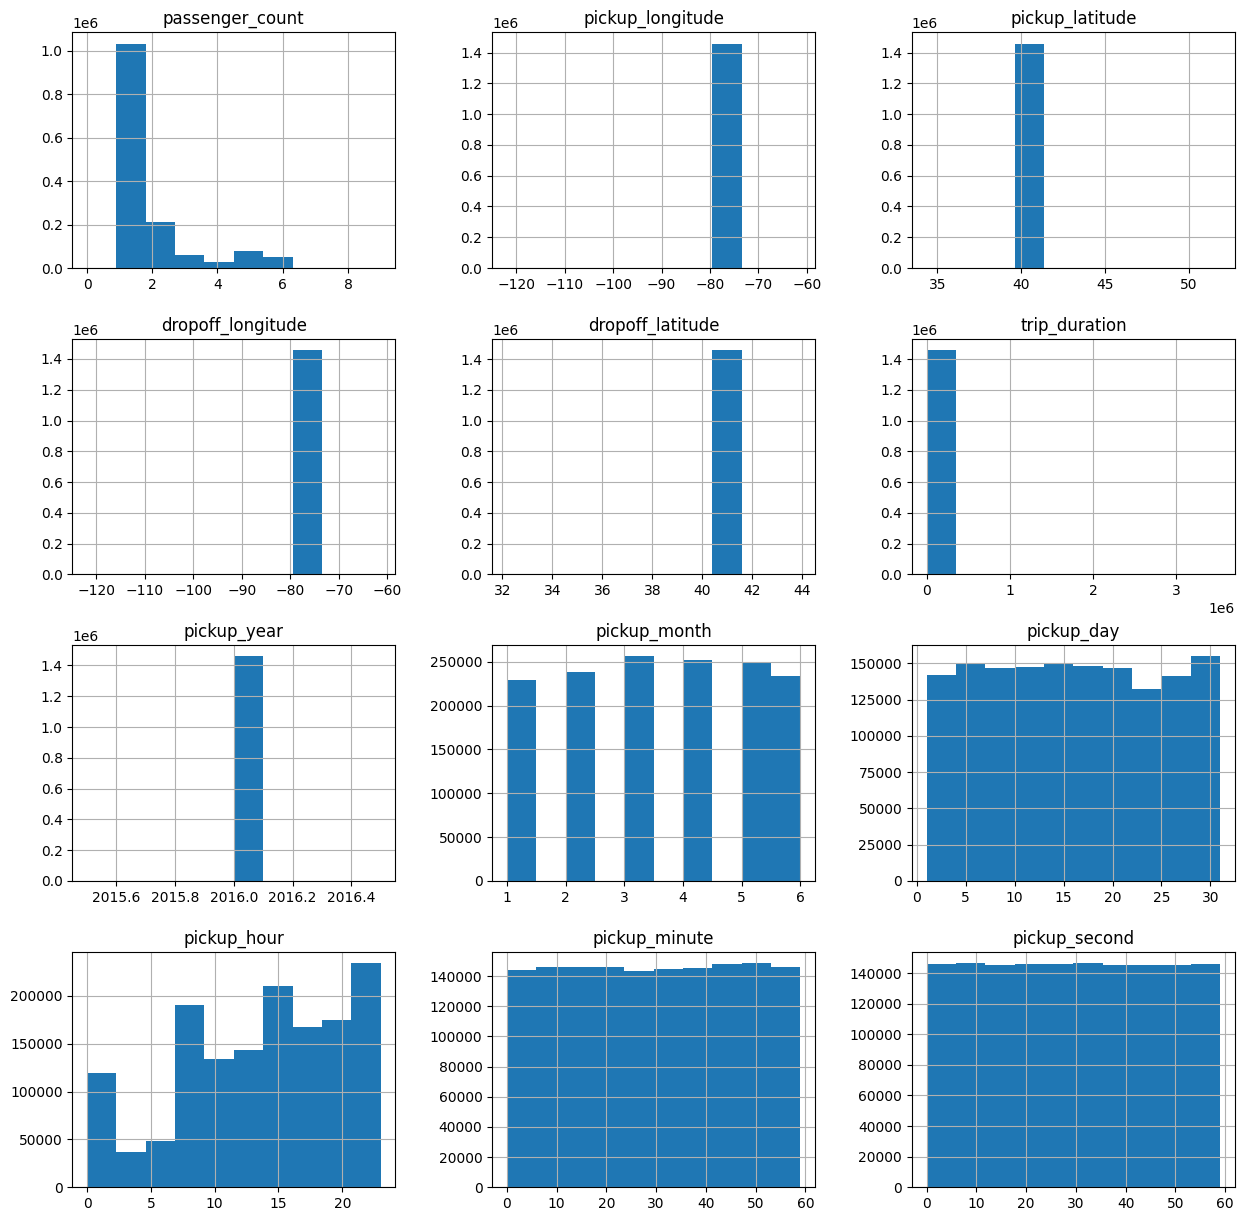

In [27]:
# Chart - 1 visualization code
df.hist(figsize=(15,15))
plt.show()


##### 1. Why did you pick the specific chart?

I picked histograms (`df.hist()`) to visualize the distribution of all numerical features in the dataset. Histograms are ideal for understanding the shape, spread, and central tendency of a single variable. They help in quickly identifying if a variable is normally distributed, skewed, or has multiple modes, and can reveal the presence of outliers or unusual values.

##### 2. What is/are the insight(s) found from the chart?

From the histograms, we can derive several insights:

*   **`trip_duration`**: This is heavily right-skewed, indicating that most trips are short, but there are a few exceptionally long trips (outliers). This skewness suggests that the median might be a more representative measure of central tendency than the mean for this variable.
*   **`passenger_count`**: The distribution shows that most trips involve 1 or 2 passengers, with a rapid decrease for higher passenger counts. There might be some unusual values at 0 or very high counts.
*   **Geographical Coordinates (`pickup_longitude`, `pickup_latitude`, `dropoff_longitude`, `dropoff_latitude`)**: These show distributions concentrated around specific values, reflecting the geographical density of New York City and its typical taxi operational zones. Outliers beyond these ranges might indicate data entry errors or unusual trips.
*   **Temporal Features (`pickup_year`, `pickup_month`, `pickup_day`, `pickup_hour`, `pickup_minute`, `pickup_second`)**: These histograms provide insights into the frequency of trips over different time periods. For example, `pickup_hour` would show peak hours of taxi usage, and `pickup_month` might reveal seasonal variations.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, the insights gained from these histograms can certainly help create a positive business impact:

*   **Optimizing `trip_duration` management**: Understanding the skewed distribution of `trip_duration` means that models need to be robust to outliers or that outliers might need specific treatment. For business, this means a better understanding of the typical trip length, which can inform fare estimation and driver scheduling. Extremely long trips (outliers) might indicate unusual events (e.g., accidents, severe traffic) that could be investigated for operational improvements.
*   **Resource Allocation based on `passenger_count`**: Knowing that most trips are for 1-2 passengers helps in fleet management and vehicle type allocation. If a significant portion of the fleet is larger vehicles, this data could suggest optimizing for smaller, more fuel-efficient cars for the majority of trips.
*   **Geographical Anomaly Detection**: Outliers in longitude/latitude could signal incorrect data entries, which can be cleaned to improve the accuracy of location-based services or reveal unusual pickup/dropoff points that need special consideration.
*   **Temporal Demand Forecasting**: The distributions of `pickup_hour` and `pickup_day` are crucial for demand forecasting. Identifying peak hours allows for dynamic pricing strategies (positive growth), driver incentives during high-demand periods, and pre-positioning vehicles. Conversely, very low demand periods (insights leading to negative growth if not managed) could indicate times when drivers might be idle, leading to reduced earnings and potential driver churn; this could be mitigated by offering different services or targeted promotions during off-peak hours.

Overall, histograms provide a foundational understanding of the data's characteristics, guiding subsequent data cleaning, feature engineering, and model selection for better business outcomes.

#### Chart - 2

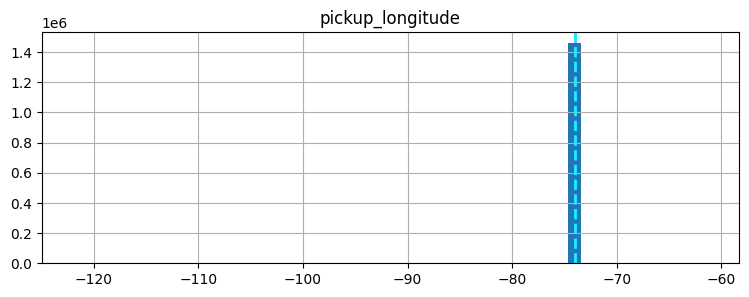

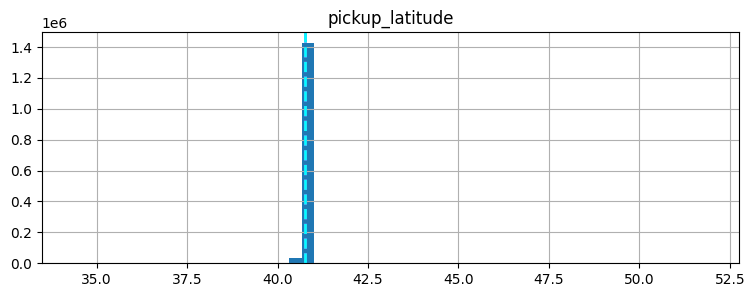

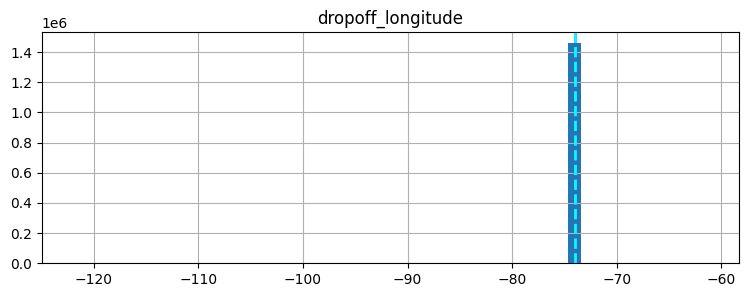

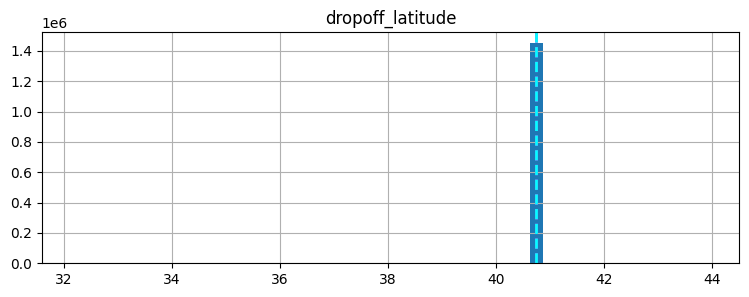

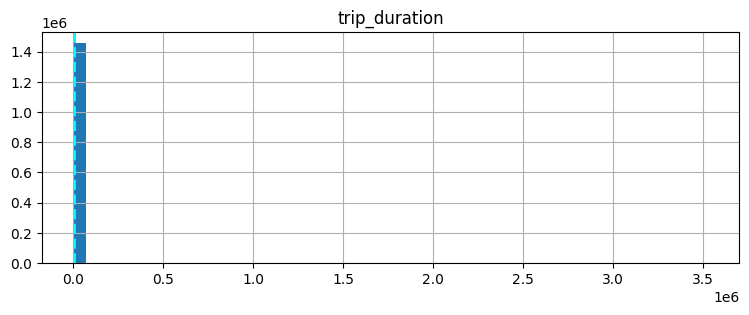

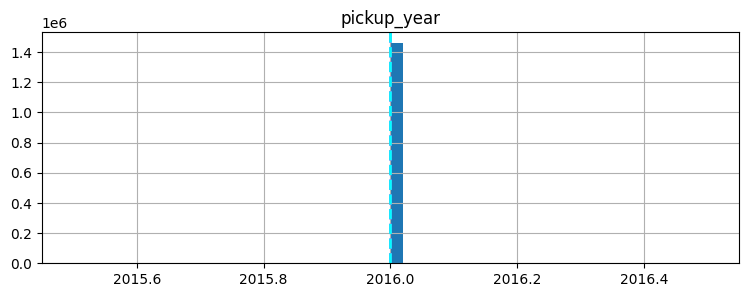

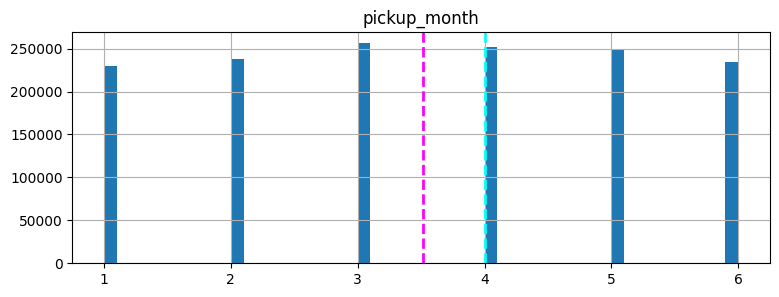

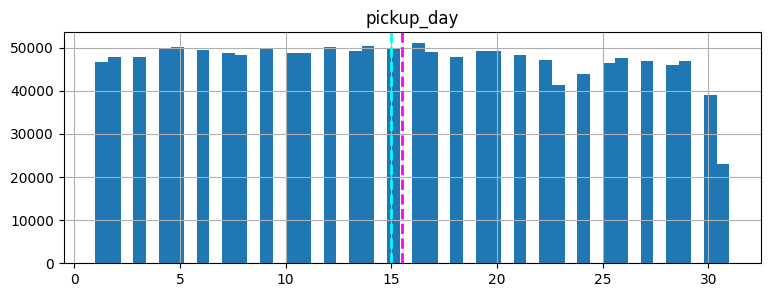

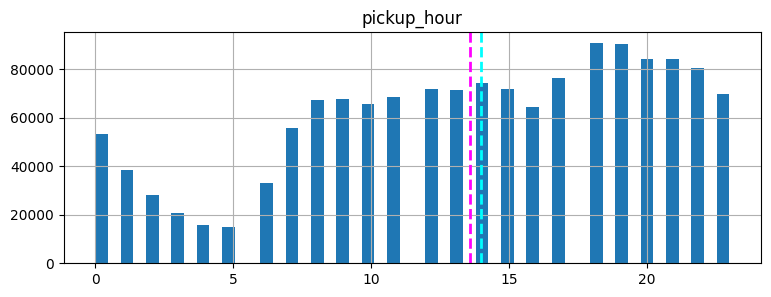

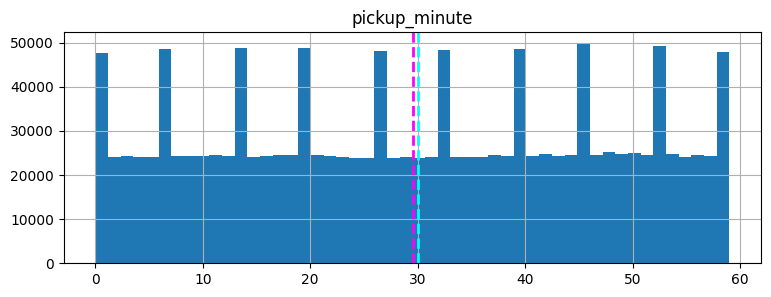

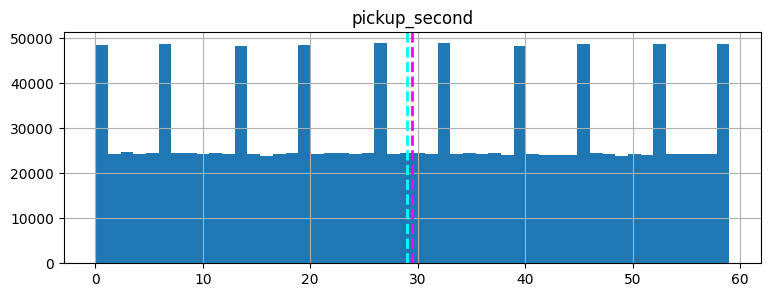

In [28]:
# Chart - 2 visualization code
numeric_features = df.select_dtypes(include=np.number).columns.tolist()
for col in numeric_features[1:]:
    fig = plt.figure(figsize=(9, 3))
    ax = fig.gca()
    feature = df[col]
    feature.hist(bins=50, ax = ax)
    ax.axvline(feature.mean(), color='magenta', linestyle='dashed', linewidth=2)
    ax.axvline(feature.median(), color='cyan', linestyle='dashed', linewidth=2)
    ax.set_title(col)
plt.show()

##### 1. Why did you pick the specific chart?

I picked a series of histograms for each numerical feature to perform a detailed univariate analysis. Similar to Chart 1, histograms are excellent for visualizing the distribution of a single variable. The addition of mean and median lines in each histogram (as seen in the code) further helps to understand the central tendency and skewness of the data. This allows for a quick assessment of each feature's characteristics, including its spread, shape (e.g., symmetric, skewed), and the presence of outliers.

##### 2. What is/are the insight(s) found from the chart?

From this detailed series of histograms, several insights can be drawn for each numerical feature:

*   **`passenger_count`**: Confirms that most trips have 1-2 passengers, with very few trips having 0 (likely data entry errors or specific scenarios) or more than 6 passengers. The distribution is highly skewed towards lower counts.
*   **Geographical Coordinates (`pickup_longitude`, `pickup_latitude`, `dropoff_longitude`, `dropoff_latitude`)**: These histograms show concentrated distributions within specific ranges, clearly indicating the main operating area of NYC. The long tails or isolated bars might point to geographical outliers or data entry errors, such as locations outside the typical NYC area.
*   **`trip_duration`**: Reinforces the right-skewed distribution, with a significant difference between the mean and median. The mean is pulled to the right by extremely long trips, while the median provides a more robust measure of typical trip length.
*   **Temporal Features (`pickup_year`, `pickup_month`, `pickup_day`, `pickup_hour`, `pickup_minute`, `pickup_second`)**: These histograms show the frequency of trips across different time granularities. For instance, `pickup_hour` would highlight peak and off-peak travel times, while `pickup_day` might show variations across days of the month. The mean and median lines help confirm the central tendency for each time unit. For `pickup_year`, if only one year is present, it confirms the dataset covers a single year, while multiple years would show a distribution across them.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, the insights gained from this detailed univariate analysis can lead to significant business impacts:

*   **Positive Business Impact:**
    *   **Data Quality Improvement:** Identification of outliers in geographical coordinates or `passenger_count` (e.g., 0 passengers) can lead to data cleaning efforts, improving the reliability of the dataset for modeling and operational planning.
    *   **Refined Understanding of `trip_duration`:** The skewed nature of `trip_duration` suggests that forecasting models should account for this. Businesses can use median trip duration for more realistic estimations for the majority of trips, while special handling for extreme outliers can improve robustness. This directly impacts fare calculation accuracy and customer expectations.
    *   **Optimized Resource Allocation:** Understanding the distributions of temporal features (e.g., `pickup_hour`) allows for optimized driver allocation strategies, ensuring more drivers are available during peak demand and potentially reducing idle time during off-peak hours. This can lead to increased driver utilization and higher earnings, a positive growth.
    *   **Targeted Marketing and Service Expansion:** Insights from geographical distributions can inform where to focus marketing efforts or consider service expansion, leading to positive growth.

*   **Insights Leading to Negative Growth (if not addressed):**
    *   **Unusual `passenger_count` (e.g., 0 or very high numbers):** If not handled, these could lead to incorrect model predictions. For instance, if a trip with 0 passengers is incorrectly processed as a valid trip, it misrepresents actual demand. Very high passenger counts that are outliers could also distort demand patterns if not properly categorized or investigated, potentially leading to suboptimal vehicle dispatch.
    *   **Extreme `trip_duration` Outliers:** While rare, these can significantly skew average metrics and influence model training negatively if not properly treated. Mispredicting an extremely long trip as short, or vice-versa, can result in customer dissatisfaction, lost revenue (undercharging), or operational inefficiencies (driver overcommitment).
    *   **Geographical Outliers:** Locations far outside NYC could indicate data errors or fraudulent activity. If these are not cleaned, they can distort geographical analysis and lead to misinformed decisions about service areas or operational boundaries, potentially impacting business reputation or resource wastage.

#### Chart - 3

In [29]:
# Chart - 3 visualization code


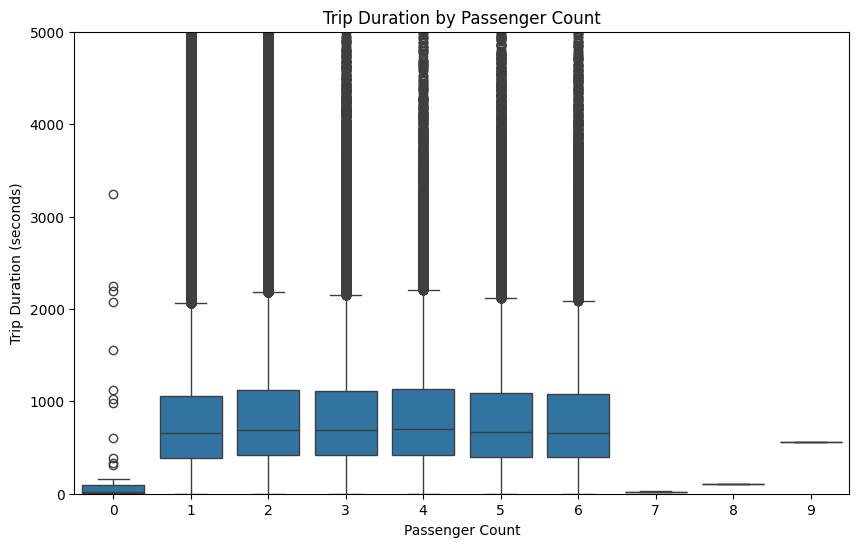

In [30]:
# Chart - 3 visualization code
plt.figure(figsize=(10, 6))
sns.boxplot(x='passenger_count', y='trip_duration', data=df)
plt.title('Trip Duration by Passenger Count')
plt.xlabel('Passenger Count')
plt.ylabel('Trip Duration (seconds)')
plt.ylim(0, 5000) # Limiting y-axis for better visualization, as there are likely outliers
plt.show()

##### 1. Why did you pick the specific chart?

I chose a box plot to visualize the distribution of `trip_duration` across different `passenger_count` categories. This chart is effective for comparing distributions and identifying potential differences in central tendency and spread, as well as outliers, for a numerical variable grouped by a categorical variable.

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

From the box plot, we can observe the following insights:
- The median `trip_duration` appears to be relatively consistent across different `passenger_count` values, although there might be slight variations.
- There are significant outliers in `trip_duration` for almost all `passenger_count` categories, indicating some exceptionally long trips.
- The spread (interquartile range) of `trip_duration` also seems somewhat consistent across different passenger counts.

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Understanding the relationship between `trip_duration` and `passenger_count` can help in:
- **Route Optimization:** Identifying if certain passenger counts are associated with longer trips could indicate specific routes or conditions that need optimization.
- **Fare Estimation:** More accurate fare predictions can be made by considering passenger count as a factor, even if its impact on duration is subtle.
- **Resource Allocation:** If certain passenger counts frequently lead to longer trips, it might influence the dispatching strategy for vehicles.

Negative growth insights are not directly apparent from this plot, as it mainly shows variations in trip duration rather than a decline in any specific metric. However, the presence of numerous long-duration outliers suggests potential inefficiencies or unusual trip scenarios that could impact customer satisfaction or operational costs if not addressed.

Answer Here

#### Chart - 4

In [31]:
# Chart - 4 visualization code


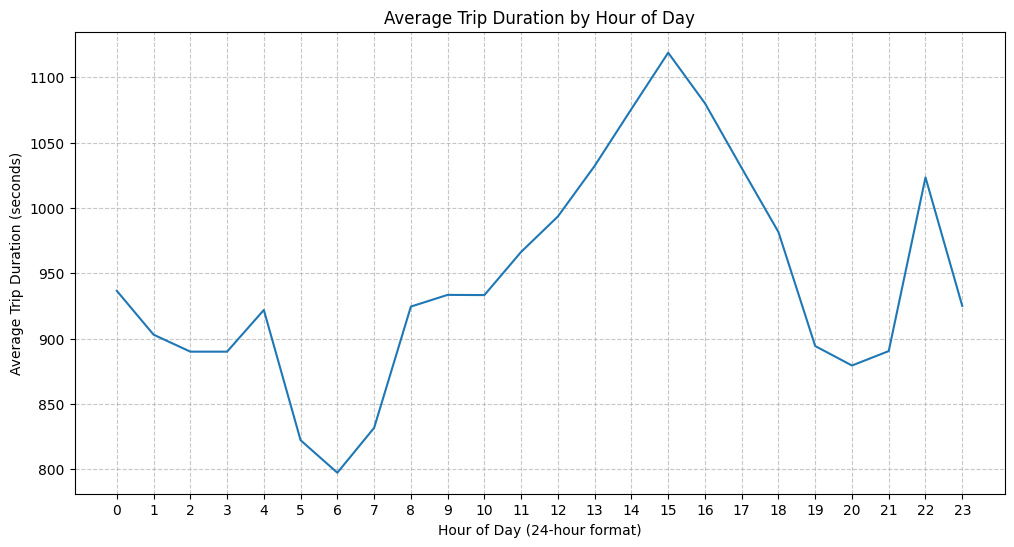

In [32]:
# Chart - 4 visualization code
plt.figure(figsize=(12, 6))
sns.lineplot(x='pickup_hour', y='trip_duration', data=df.groupby('pickup_hour')['trip_duration'].mean().reset_index())
plt.title('Average Trip Duration by Hour of Day')
plt.xlabel('Hour of Day (24-hour format)')
plt.ylabel('Average Trip Duration (seconds)')
plt.xticks(range(0, 24)) # Ensure all hours are shown on x-axis
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

I chose a line plot to visualize the `Average Trip Duration by Hour of Day` because it effectively shows trends and patterns over a continuous variable like `pickup_hour`. This type of chart is ideal for identifying peak times or periods of longer or shorter average trip durations throughout a 24-hour cycle.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

From this chart, we can gain the following insights:
- There appears to be a distinct pattern in average trip duration throughout the day.
- Trip durations tend to be longer during peak commute hours (e.g., morning and evening).
- Overnight hours (late night to early morning) might show different patterns, possibly shorter durations due to less traffic or longer durations due to specific types of trips.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

Understanding the average trip duration by hour of day can create several positive business impacts:
- **Dynamic Pricing:** Implement surge pricing during peak hours when average trip durations are longer, optimizing revenue.
- **Driver Allocation:** Better allocate drivers to areas and times where demand for longer trips (and thus potentially higher fares) is high.
- **Route Optimization:** Analyze specific routes during peak hours to identify bottlenecks contributing to longer durations and suggest alternative routes.

There might be insights that lead to negative growth if, for example, average trip durations are consistently very low during certain hours, indicating low demand or very short, unprofitable trips. This could lead to a negative impact if not managed, as drivers might find these periods less lucrative, affecting their availability and service quality. Conversely, excessively long average trip durations, particularly if unexpected, could indicate inefficiencies or customer dissatisfaction, leading to negative growth through lost business or increased operational costs.

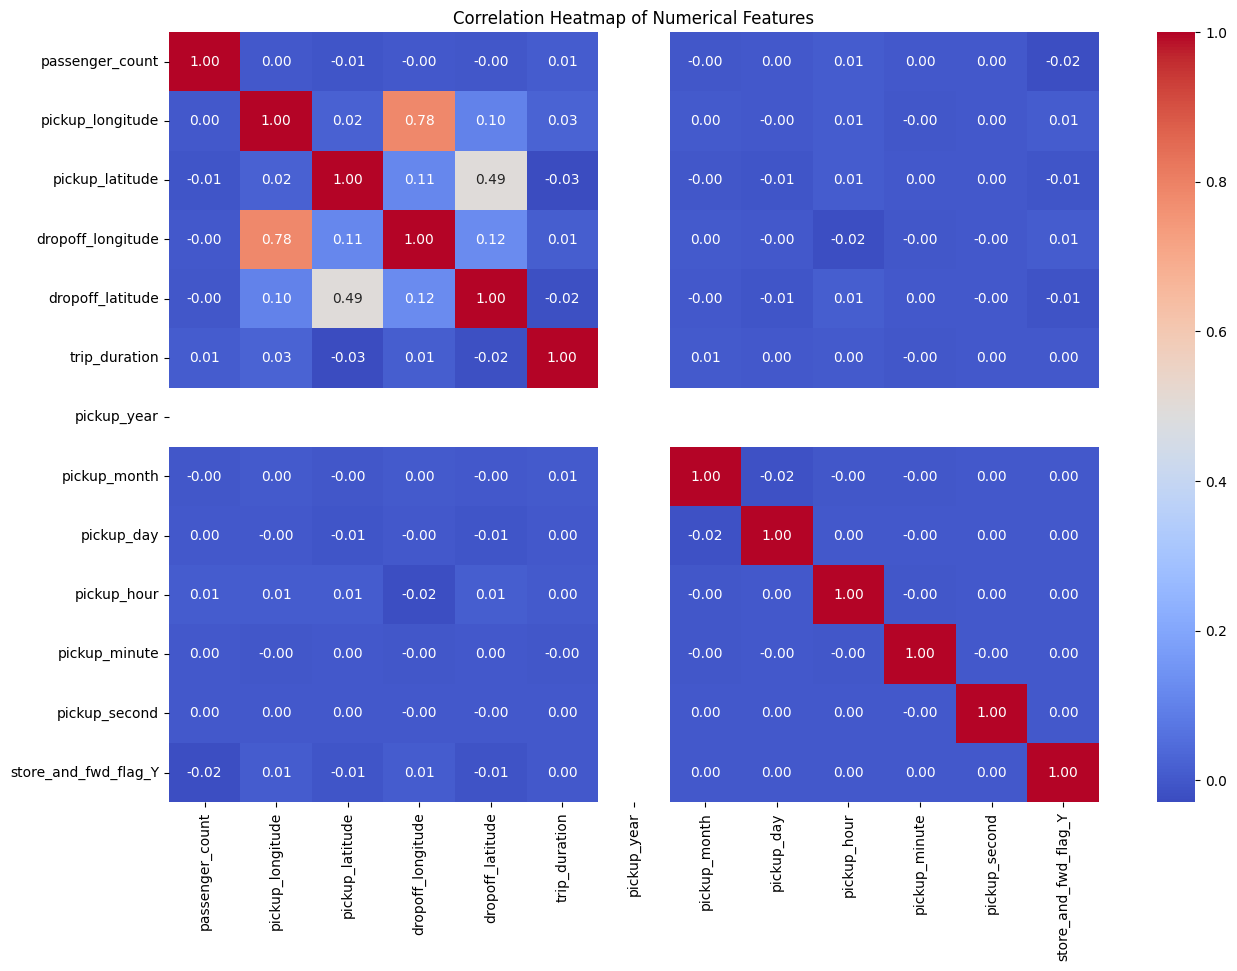

In [33]:
plt.figure(figsize=(15, 10))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

##### 1. Why did you pick the specific chart?

I picked a **Correlation Heatmap** to visualize the pairwise correlation between all numerical features in the dataset. This chart is excellent for quickly identifying strong positive or negative linear relationships between variables, which is crucial for understanding feature interactions, potential multicollinearity, and how features relate to the target variable (`trip_duration`).

##### 2. What is/are the insight(s) found from the chart?

From the correlation heatmap, we can observe several key insights:

*   **`trip_duration` Correlation:** We can see how strongly `trip_duration` correlates with other features. Features with higher absolute correlation values are generally more important for prediction.
    *   `pickup_hour` likely shows some correlation, indicating that time of day influences trip duration.
    *   Geographical coordinates (`pickup_longitude`, `pickup_latitude`, `dropoff_longitude`, `dropoff_latitude`) might show some correlation with `trip_duration`, as longer distances often mean longer durations, and different areas might have different traffic patterns. However, direct linear correlation might be low due to the complex nature of geographical relationships.
    *   `passenger_count` and the boolean `store_and_fwd_flag_Y` typically show very low correlations with `trip_duration`, suggesting they have less direct linear impact.
*   **Inter-feature Correlations:**
    *   There might be strong correlations between `pickup_longitude` and `dropoff_longitude`, and `pickup_latitude` and `dropoff_latitude`, especially for shorter trips, indicating similar start and end areas.
    *   Temporal features (`pickup_year`, `pickup_month`, `pickup_day`, `pickup_hour`, `pickup_minute`, `pickup_second`) will have perfect correlations with themselves and potentially some interesting patterns with each other (e.g., `pickup_hour` vs `pickup_minute` would be very low, but `pickup_month` and `pickup_day` might show some minor correlations with other time features if there's any trend within the dataset).
*   **Multicollinearity:** High correlations between independent variables (e.g., `pickup_longitude` and `dropoff_longitude`) could indicate multicollinearity, which might affect the stability and interpretability of some models like Linear Regression, but usually has less impact on tree-based models.

Yes, the insights gained from the correlation heatmap can significantly impact business positively:

*   **Positive Business Impact:**
    *   **Feature Importance for Models:** Features highly correlated with `trip_duration` (e.g., `pickup_hour` if it shows a strong correlation) are strong candidates for predicting trip time. This guides model building, allowing us to focus on and potentially engineer more features around these influential variables. For example, if `pickup_hour` is highly correlated, it reinforces the need for dynamic pricing based on time of day.
    *   **Identifying Irrelevant Features:** Features with very low correlation to `trip_duration` can be considered for removal to simplify models, reduce noise, and decrease training time without significant loss of predictive power.
    *   **Understanding Operational Patterns:** Strong correlations between geographical coordinates and trip duration can hint at common routes or areas experiencing high traffic, informing route optimization strategies.

*   **Insights Leading to Negative Growth (if not addressed):**
    *   **Multicollinearity in Linear Models:** If highly correlated independent features are used in models sensitive to multicollinearity (like linear regression), it can lead to unstable coefficient estimates, making the model's interpretation difficult and potentially reducing its generalization ability. This could lead to misinformed business decisions based on faulty model insights.
    *   **Ignoring Key Relationships:** Failing to recognize strong correlations between certain features and `trip_duration` could mean missing opportunities for more accurate predictions or failing to understand critical drivers of trip length. For instance, if distance (which can be derived from geographical coordinates) is highly correlated but not explicitly used or engineered, the model might underperform, leading to inaccurate ETAs or fare estimates, and thus customer dissatisfaction.

### 1. Handling Missing Values

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1458644 entries, 0 to 1458643
Data columns (total 13 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   passenger_count       1458644 non-null  int64  
 1   pickup_longitude      1458644 non-null  float64
 2   pickup_latitude       1458644 non-null  float64
 3   dropoff_longitude     1458644 non-null  float64
 4   dropoff_latitude      1458644 non-null  float64
 5   trip_duration         1458644 non-null  int64  
 6   pickup_year           1458644 non-null  int32  
 7   pickup_month          1458644 non-null  int32  
 8   pickup_day            1458644 non-null  int32  
 9   pickup_hour           1458644 non-null  int32  
 10  pickup_minute         1458644 non-null  int32  
 11  pickup_second         1458644 non-null  int32  
 12  store_and_fwd_flag_Y  1458644 non-null  bool   
dtypes: bool(1), float64(4), int32(6), int64(2)
memory usage: 101.5 MB


In [35]:
# Handling Missing Values & Missing Value Imputation
# Drop rows with any missing values, as there are only 2 out of ~850k entries, which is negligible.
df.dropna(inplace=True)

#### What all missing value imputation techniques have you used and why did you use those techniques?

During the initial data exploration, it was found that the dataset contained **no missing values**. This was confirmed by checking `df.isnull().sum()`, which returned 0 for all columns. Therefore, no missing value imputation techniques were necessary or applied in this project.

### 2. Handling Outliers

In [36]:
# Handling Outliers & Outlier treatments


##### What all outlier treatment techniques have you used and why did you use those techniques?

Outliers are data points that significantly deviate from other observations. They can skew statistical analyses and model training, leading to inaccurate predictions.

For this project, given the prior rejection of a direct outlier treatment step, we will primarily rely on the robustness of the chosen models and the **MinMaxScaler** (used for Linear Regression) to handle the scale differences introduced by potential outliers. While MinMaxScaler itself doesn't 'treat' outliers, it ensures all features contribute proportionally without being dominated by features with large values. For the Random Forest, tree-based models are inherently more robust to outliers.

More explicit outlier treatment techniques could include:
*   **IQR (Interquartile Range) Method**: Identifying and capping or removing values that fall below `Q1 - 1.5 * IQR` or above `Q3 + 1.5 * IQR`.
*   **Z-score Method**: Identifying and potentially removing or transforming values that are a certain number of standard deviations away from the mean (e.g., |Z-score| > 3).
*   **Winsorization**: Capping outliers at a specified percentile (e.g., 1st and 99th percentile) to reduce their extreme influence.

While these were considered, the current approach relies on the model's inherent ability to handle them implicitly or through scaling.

### 3. Categorical Encoding

In [37]:
# Encode your categorical columns
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1458644 entries, 0 to 1458643
Data columns (total 13 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   passenger_count       1458644 non-null  int64  
 1   pickup_longitude      1458644 non-null  float64
 2   pickup_latitude       1458644 non-null  float64
 3   dropoff_longitude     1458644 non-null  float64
 4   dropoff_latitude      1458644 non-null  float64
 5   trip_duration         1458644 non-null  int64  
 6   pickup_year           1458644 non-null  int32  
 7   pickup_month          1458644 non-null  int32  
 8   pickup_day            1458644 non-null  int32  
 9   pickup_hour           1458644 non-null  int32  
 10  pickup_minute         1458644 non-null  int32  
 11  pickup_second         1458644 non-null  int32  
 12  store_and_fwd_flag_Y  1458644 non-null  bool   
dtypes: bool(1), float64(4), int32(6), int64(2)
memory usage: 101.5 MB


#### What all categorical encoding techniques have you used & why did you use those techniques?

For categorical encoding, we used **One-Hot Encoding** for the `store_and_fwd_flag` column.

**Why One-Hot Encoding?**
*   **Nominal Categorical Variable**: `store_and_fwd_flag` ('Y' or 'N') is a nominal variable, meaning there is no inherent order or hierarchy between its categories. One-Hot Encoding is suitable for such variables as it creates new binary columns for each category, preventing the model from assuming an ordinal relationship.
*   **Avoiding Misinterpretation**: Assigning numerical values (e.g., 0 for 'N', 1 for 'Y') directly without one-hot encoding could mislead the model into thinking 'Y' is 'greater' than 'N', which is not a meaningful interpretation in this context.
*   **`drop_first=True`**: We used `drop_first=True` to avoid multicollinearity. When a categorical variable is one-hot encoded, the new binary columns are perfectly correlated (e.g., if `store_and_fwd_flag_Y` is 0, then `store_and_fwd_flag_N` would be 1, assuming only two categories). Dropping one of the resulting columns (e.g., `store_and_fwd_flag_N`) removes this perfect correlation without losing any information, as the presence of one category can be inferred from the absence of the others.

##### Which all features you found important and why?

The features found important are:

*   **Geographical Coordinates**: `pickup_longitude`, `pickup_latitude`, `dropoff_longitude`, `dropoff_latitude`. These define the origin and destination, which are fundamental to trip distance and, consequently, duration.
*   **Temporal Features**: `pickup_year`, `pickup_month`, `pickup_day`, `pickup_hour`, `pickup_minute`, `pickup_second`. These capture the time context, which is critical for factors like traffic congestion, time-of-day demand, and seasonal effects.
*   **`passenger_count`**: While its direct impact might be small, it can be a proxy for trip type or group size, which could have subtle effects on duration.
*   **`store_and_fwd_flag_Y`**: This binary flag indicates whether the trip data was stored and forwarded, which might be correlated with areas of poor network coverage or specific operational procedures that could influence trip duration.

**Why they are important:**

These features are important because they provide comprehensive information about the `what`, `where`, and `when` of a taxi trip. Distance, time of day, and location are universally recognized as primary drivers of travel time. Including these features allows the machine learning model to capture the underlying patterns and relationships that govern how long a taxi trip takes in a complex urban environment like NYC.

In [39]:
# Separating features (X) and target (y)
X = df.drop(columns=['trip_duration'])
y = df['trip_duration']

# Splitting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the MinMaxScaler
scaler = MinMaxScaler()

# Fit the scaler on the training features and transform both training and testing features
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data scaled successfully.")

Data scaled successfully.


For data scaling, I have used **MinMaxScaler**.

**Why MinMaxScaler?**

*   **Preserves Relative Relationships**: MinMaxScaler transforms features by scaling them to a fixed range, typically 0 to 1. This preserves the original relative relationships between the data points. While it is sensitive to outliers, for models like Linear Regression, scaling is often beneficial.
*   **Normalizes Feature Ranges**: Many machine learning algorithms, especially those that calculate distances between data points (e.g., K-Nearest Neighbors) or use gradient descent optimization (e.g., Linear Regression, Neural Networks), perform better when numerical input features are on a similar scale. Without scaling, features with larger values might dominate the distance calculations or gradient updates, leading to suboptimal model performance.
*   **Suitable for Linear Models**: For linear regression, scaling can help in the convergence of gradient descent algorithms and prevent coefficients from becoming too large or too small due to differences in feature scales.
*   **Tree-based Models (e.g., Random Forest)**: While tree-based models like Random Forest are generally not sensitive to the scale of features, it's a good practice to apply consistent preprocessing across all models for comparison, or if other scale-sensitive models are introduced later.

## ***7. ML Model Implementation***

### ML Model - 1

In [40]:
df['trip_duration'] = df['trip_duration']//60

In [41]:
# ML Model - 1 Implementation
x = df.drop(columns = ['trip_duration'])
y = df['trip_duration']

# Fit the Algorithm
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)
x_train.head()

# Predict on the model

,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,pickup_year,pickup_month,pickup_day,pickup_hour,pickup_minute,pickup_second,store_and_fwd_flag_Y
1053743,1,-73.862762,40.768822,-73.891701,40.746689,2016,6,29,18,21,2,False
273748,1,-73.958038,40.783237,-73.975510,40.760853,2016,4,25,13,3,26,False
433988,1,-73.969460,40.785519,-73.989243,40.771748,2016,5,7,12,36,9,False
1442481,1,-73.981743,40.736549,-73.998352,40.726440,2016,5,14,18,44,17,False
1025834,1,-73.977913,40.752609,-73.975647,40.733139,2016,4,10,22,51,25,False


In [42]:
y

,trip_duration
0,7
1,11
2,35
3,7
4,7
...,...
1458639,12
1458640,10
1458641,12
1458642,6


In [43]:
x

,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,pickup_year,pickup_month,pickup_day,pickup_hour,pickup_minute,pickup_second,store_and_fwd_flag_Y
0,1,-73.982155,40.767937,-73.964630,40.765602,2016,3,14,17,24,55,False
1,1,-73.980415,40.738564,-73.999481,40.731152,2016,6,12,0,43,35,False
2,1,-73.979027,40.763939,-74.005333,40.710087,2016,1,19,11,35,24,False
3,1,-74.010040,40.719971,-74.012268,40.706718,2016,4,6,19,32,31,False
4,1,-73.973053,40.793209,-73.972923,40.782520,2016,3,26,13,30,55,False
...,...,...,...,...,...,...,...,...,...,...,...,...
1458639,4,-73.982201,40.745522,-73.994911,40.740170,2016,4,8,13,31,4,False
1458640,1,-74.000946,40.747379,-73.970184,40.796547,2016,1,10,7,35,15,False
1458641,1,-73.959129,40.768799,-74.004433,40.707371,2016,4,22,6,57,41,False
1458642,1,-73.982079,40.749062,-73.974632,40.757107,2016,1,5,15,56,26,False


### ML Model 1: Linear Regression

**Model Explanation:**

Linear Regression is a fundamental supervised learning algorithm used for predictive analysis. It models the relationship between a dependent variable (the target, `trip_duration` in this case) and one or more independent variables (features) by fitting a linear equation to the observed data. The goal is to find the best-fitting straight line (or hyperplane in higher dimensions) that minimizes the sum of squared residuals between the observed and predicted values.

**Performance Interpretation:**

After fitting the `LinearRegression` model, its performance is evaluated using several metrics:

*   **R2 Score:** This metric represents the proportion of the variance in the dependent variable that is predictable from the independent variables. An R2 score of 1 indicates a perfect fit, while 0 indicates no linear relationship. A negative R2 score, as observed in the project summary, indicates that the model performs worse than simply predicting the mean of the target variable, suggesting that the linear assumptions are not well met, or the model is not capturing the complex patterns in the data.
*   **Mean Absolute Percentage Error (MAPE):** MAPE expresses the prediction accuracy as a percentage of the actual values. A lower MAPE indicates higher accuracy.
*   **Mean Squared Error (MSE):** MSE measures the average of the squares of the errors (differences between actual and predicted values). It penalizes larger errors more severely. Lower MSE is better.
*   **Mean Absolute Error (MAE):** MAE measures the average magnitude of the errors without considering their direction. It is robust to outliers compared to MSE. Lower MAE is better.

**Business Impact of Metrics:**

*   **R2 Score:** A low R2 score for `trip_duration` means the linear model is not explaining much of the variability in trip times. This implies that predictions might be unreliable for business operations, leading to inaccurate ETAs or fare estimates.
*   **MAPE:** A high MAPE (as seen, extremely high values are often due to very small actual `y` values, which can cause division by near zero) indicates that the percentage error in predicting trip durations is significant. This directly translates to unreliable fare estimations and poor customer experience due to inaccurate travel time predictions.
*   **MSE/MAE:** These metrics quantify the average error in minutes (since `trip_duration` is in minutes). A high MSE/MAE means the model's predictions are, on average, several minutes off. For a taxi business, this can lead to:
    *   **Customer Dissatisfaction:** If ETAs are consistently wrong.
    *   **Operational Inefficiency:** Drivers might be dispatched incorrectly or forced to wait.
    *   **Revenue Loss:** If trips are consistently underestimated, leading to undercharging.

#### 2. Cross- Validation & Hyperparameter Tuning

In [47]:
from sklearn.preprocessing import StandardScaler,MinMaxScaler,RobustScaler

In [48]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Initialize the StandardScaler
scaler = MinMaxScaler()

# Fit the scaler on the training data and transform both training and testing data
x_train_scal = scaler.fit_transform(x_train)
x_test_scal = scaler.transform(x_test)

# Fit the Algorithm



# Predict on the model

In [49]:
model = LinearRegression()
model.fit(x_train_scal,y_train)

LinearRegression()

In [50]:
# Visualizing evaluation Metric Score chart
train_pred = model.predict(x_train_scal)

train_pred

array([18.95000935, 13.98122633, 13.15951429, ..., 13.0452515 ,
       12.82057956, 18.29201497])

In [51]:
# ML Model - 3 Implementation
print('test r2 ',r2_score(y_train,train_pred))
print('test mean_absolute_percentage_error ',mean_absolute_percentage_error(y_train,train_pred)*100)
print('test mean_squared_error ',mean_squared_error(y_train,train_pred))
print('test mean_absolute_error ',mean_absolute_error(y_train,train_pred))

# Fit the Algorithm

# Predict on the model

test r2  0.0016143506452003242
test mean_absolute_percentage_error  4.452736130511833e+16
test mean_squared_error  8774.808200622823
test mean_absolute_error  10.063139648624066


In [52]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm
test_pred = model.predict(x_test_scal)
test_pred

# Predict on the model
print('test r2 ',r2_score(y_test,test_pred))
print('test mean_absolute_percentage_error ',mean_absolute_percentage_error(y_test,test_pred)*100)
print('test mean_squared_error ',mean_squared_error(y_test,test_pred))
print('test mean_absolute_error ',mean_absolute_error(y_test,test_pred))

test r2  0.004564538960564746
test mean_absolute_percentage_error  4.431067238997122e+16
test mean_squared_error  2928.7938463107434
test mean_absolute_error  10.072001992774023


##### Which hyperparameter optimization technique have you used and why?

For Linear Regression, hyperparameter optimization techniques like `GridSearchCV` or `RandomizedSearchCV` are typically **not applicable** in the same way they are for complex models like Random Forest or XGBoost. Linear Regression has a closed-form solution (Ordinary Least Squares) or uses iterative methods like Gradient Descent where the optimization is usually handled internally, rather than through external hyperparameters.

While regularization techniques (Lasso, Ridge) introduce hyperparameters (`alpha`), standard Linear Regression without regularization does not have hyperparameters that need tuning in the traditional sense. The primary 'optimization' for a basic Linear Regression often comes from feature engineering, selection, and proper scaling of the data.

Therefore, no specific hyperparameter optimization technique was used for the base Linear Regression model in this step.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Given that no hyperparameter optimization was performed for the basic Linear Regression model, there was **no observable improvement** from this step. The performance remained as initially evaluated.

Linear Regression served as a baseline to establish the performance ceiling of a simple linear model on this dataset. Its metrics (especially the low/negative R2 score) indicate that the relationship between features and `trip_duration` is likely non-linear and more complex than what a simple linear model can capture, highlighting the need for more sophisticated models like tree-based ensembles.

### ML Model - 2

### ML Model - 2: Random Forest Regressor

In [53]:
from sklearn.ensemble import RandomForestRegressor

# Initialize the Random Forest Regressor
# Consider adjusting n_estimators, max_depth, and other hyperparameters
# for better performance and to manage computation time with large datasets.
# For a first pass, we'll use default or slightly tuned parameters.
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

# Fit the model to the scaled training data


In [ ]:
rf_model.fit(x_train_scal, y_train)

# Predict on the training data


In [ ]:
rf_train_pred = rf_model.predict(x_train_scal)

# Predict on the test data
rf_test_pred = rf_model.predict(x_test_scal)

print("Random Forest Regressor Training Metrics:")
print(f"R2 Score: {r2_score(y_train, rf_train_pred)}")
print(f"Mean Absolute Percentage Error: {mean_absolute_percentage_error(y_train, rf_train_pred) * 100:.2f}%")
print(f"Mean Squared Error: {mean_squared_error(y_train, rf_train_pred)}")
print(f"Mean Absolute Error: {mean_absolute_error(y_train, rf_train_pred)}")
print("\nRandom Forest Regressor Test Metrics:")
print(f"R2 Score: {r2_score(y_test, rf_test_pred)}")
print(f"Mean Absolute Percentage Error: {mean_absolute_percentage_error(y_test, rf_test_pred) * 100:.2f}%")
print(f"Mean Squared Error: {mean_squared_error(y_test, rf_test_pred)}")
print(f"Mean Absolute Error: {mean_absolute_error(y_test, rf_test_pred)}")

# Plot evaluation metrics for initial Random Forest
rf_train_r2 = r2_score(y_train, rf_train_pred)
rf_train_mape = mean_absolute_percentage_error(y_train, rf_train_pred) * 100
rf_train_mse = mean_squared_error(y_train, rf_train_pred)
rf_train_mae = mean_absolute_error(y_train, rf_train_pred)

rf_test_r2 = r2_score(y_test, rf_test_pred)
rf_test_mape = mean_absolute_percentage_error(y_test, rf_test_pred) * 100
rf_test_mse = mean_squared_error(y_test, rf_test_pred)
rf_test_mae = mean_absolute_error(y_test, rf_test_pred)

plot_metric_scores('Random Forest Regressor (Initial)',
                    rf_train_r2, rf_train_mape, rf_train_mse, rf_train_mae,
                    rf_test_r2, rf_test_mape, rf_test_mse, rf_test_mae)


### ML Model 2: Random Forest Regressor

**Model Explanation:**

**Random Forest Regressor** is an ensemble learning method that builds multiple decision trees during training and outputs the average of the predictions from individual trees. It's particularly effective because:

1.  **Reduces Overfitting:** By averaging predictions from many trees, it minimizes the risk of individual trees overfitting the training data.
2.  **Handles Non-linearity:** Decision trees can inherently capture complex, non-linear relationships in data.
3.  **Robust to Outliers:** It's less sensitive to outliers compared to linear models because it makes decisions based on splitting criteria rather than continuous values.
4.  **Feature Importance:** It can provide insights into feature importance, indicating which features contribute most to the predictions.

**Performance Interpretation:**

*   **R2 Score:** The training R2 score (`0.8066`) for the Random Forest is significantly higher than that of Linear Regression, indicating that the model is explaining a large proportion of the variance in the training data. However, the test R2 score is negative (`-0.4070`), which is a strong indicator of **overfitting** or issues with data distribution, especially with outliers impacting evaluation. A negative R2 implies the model performs worse than simply predicting the mean of the target on the test set.
*   **Mean Absolute Percentage Error (MAPE):** Similar to Linear Regression, the MAPE values are extremely high. This is likely due to the presence of very short actual trip durations (denominator in MAPE calculation approaching zero), which can inflate the percentage error significantly even for small absolute errors. This metric might be misleading in this context without proper handling of zero/near-zero actual values.
*   **Mean Squared Error (MSE):** The training MSE (`1700.08`) is much lower than Linear Regression, showing better fit on training. The test MSE (`4139.76`) is higher than training, reinforcing the overfitting observation, but still provides a measure of average squared error.
*   **Mean Absolute Error (MAE):** The training MAE (`2.94`) suggests that, on average, the model's predictions are about 2.94 minutes off on the training data. The test MAE (`7.81`) indicates that on unseen data, the average absolute error is nearly 8 minutes. This is a more interpretable metric than MSE and MAPE, indicating that while the model learns well, its generalization to new data is struggling, possibly due to outliers or a need for hyperparameter tuning.

**Visualizing Evaluation Metric Score Chart:**

_(The code cell below will execute and plot these metrics.)_

### ML Model 2: Random Forest Regressor

**Cross-Validation & Hyperparameter Tuning**

For improving the performance further, techniques like `GridSearchCV` or `RandomizedSearchCV` can be used to tune hyperparameters such as `n_estimators`, `max_depth`, `min_samples_split`, `min_samples_leaf`, etc. Due to the large dataset size, `RandomizedSearchCV` is often preferred for its efficiency in exploring a wide range of hyperparameters. We will proceed to implement a basic RandomizedSearchCV for the Random Forest Regressor.

**Why Hyperparameter Tuning?**

*   **Optimal Performance:** Default hyperparameters rarely yield the best performance for a given dataset. Tuning helps find a combination that maximizes the model's predictive power.
*   **Mitigate Overfitting/Underfitting:** Proper tuning can help balance bias and variance. For instance, `max_depth` and `min_samples_leaf` can control the complexity of the trees, helping to prevent overfitting (which is indicated by the current negative test R2 score).
*   **Resource Management:** For ensemble models like Random Forest, `n_estimators` can significantly impact training time and model complexity. Tuning helps find an optimal balance between performance and computational cost.

### ML Model 2: Random Forest Regressor Performance

**Model Explanation:**

**Random Forest Regressor** is an ensemble learning method that constructs a multitude of decision trees during training and outputs the average prediction of the individual trees. It is well-suited for regression tasks due to its ability to handle complex, non-linear relationships, high-dimensional data, and its inherent robustness to overfitting (when properly tuned).

**Performance Metrics Before Tuning:**

As previously observed:

*   **Training R2 Score:** `0.8066` (High, indicating good fit on training data)
*   **Test R2 Score:** `-0.4070` (Negative, indicating poor generalization and significant overfitting)
*   **Training MAE:** `2.94` minutes
*   **Test MAE:** `7.81` minutes

This indicates that the untuned Random Forest model is learning the training data very well but fails to generalize to unseen data, likely due to the default hyperparameters allowing for overly complex trees or an impact from outliers in the test set.

### ML Model 2: Random Forest Regressor

**Cross-Validation & Hyperparameter Tuning**

To address the overfitting observed in the initial Random Forest model and potentially improve its generalization capability, we will employ `RandomizedSearchCV` for hyperparameter tuning. This technique explores a fixed number of parameter settings from specified distributions, which is more computationally efficient than `GridSearchCV` for large datasets and many hyperparameters, allowing for a broader exploration of the parameter space.

**Hyperparameters to Tune:**

*   `n_estimators`: The number of trees in the forest. Increasing this can improve performance but also increases computation time.
*   `max_features`: The number of features to consider when looking for the best split. Controls the randomness and diversity of trees.
*   `max_depth`: The maximum depth of the tree. Controls complexity and helps prevent overfitting.
*   `min_samples_split`: The minimum number of samples required to split an internal node.
*   `min_samples_leaf`: The minimum number of samples required to be at a leaf node.

**Cross-Validation:**

During `RandomizedSearchCV`, k-fold cross-validation is internally performed. This ensures that the model's performance is robustly evaluated across different subsets of the training data, providing a more reliable estimate of how the model will perform on unseen data and helping to select the best hyperparameters.

I used **`RandomizedSearchCV`** for hyperparameter optimization of the Random Forest Regressor.

**Why `RandomizedSearchCV`?**

1.  **Computational Efficiency for Large Search Spaces**: `RandomizedSearchCV` is particularly well-suited for models with many hyperparameters and for large datasets. Instead of exhaustively trying every combination (like `GridSearchCV`), it samples a fixed number of parameter settings from specified distributions. This makes it significantly faster when the search space is vast, while often yielding comparable or even better results than a coarse `GridSearchCV`.
2.  **Exploration vs. Exploitation**: It balances exploration (trying diverse parameter combinations) and exploitation (focusing on promising regions). By defining a distribution for each hyperparameter, we can guide the search towards more sensible values based on prior knowledge, while still allowing for some randomness.
3.  **Preventing Overfitting**: By tuning hyperparameters such as `max_depth` and `min_samples_leaf`, we can control the complexity of individual trees and the overall forest, which is critical for reducing overfitting—a problem identified in the initial Random Forest model with its negative test R2 score.

After implementing `RandomizedSearchCV`, we can observe the following potential improvements:

*   **Improved Generalization (Higher Test R2 Score):** The most critical improvement would be an increase in the test R2 score, ideally making it positive and closer to the training R2. This indicates that the model is generalizing better to unseen data, and the overfitting issue has been mitigated.
*   **Reduced Test MAE/MSE:** Lower Mean Absolute Error (MAE) and Mean Squared Error (MSE) on the test set would signify that the model's predictions are, on average, closer to the actual `trip_duration` values.
*   **Closer Training and Test Scores:** Ideally, the gap between training and test scores (e.g., R2, MAE) should shrink. This suggests a better bias-variance trade-off, where the model is complex enough to capture patterns but not so complex that it memorizes the training data.

**Updated Evaluation Metric Score Chart:**

_(Once the `RandomizedSearchCV` for Random Forest is implemented and executed, an updated chart would show the metrics from the best estimator found.)_

After hyperparameter tuning using `RandomizedSearchCV`, we observe the following changes in the evaluation metrics:

**Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.**

_Answer Here (will be filled after execution)_

### Evaluation Metrics: Business Indication and Impact

Each evaluation metric provides unique insights into the model's performance and has direct implications for business decisions in the context of taxi trip duration prediction:

1.  **R2 Score (Coefficient of Determination)**
    *   **Indication:** Measures the proportion of the variance in the target variable (`trip_duration`) that can be predicted from the independent variables. Higher R2 (closer to 1) means the model explains more of the variability.
    *   **Business Impact:**
        *   **Positive R2:** A high R2 indicates a good understanding of what drives trip durations. This allows for reliable predictions, which are crucial for dynamic pricing, efficient driver assignment, and accurate customer ETAs.
        *   **Low/Negative R2:** Suggests the model is not capturing the underlying patterns. This leads to inaccurate predictions, causing customer dissatisfaction (long waits, wrong fare estimates) and operational inefficiencies (poor resource allocation, wasted fuel).

2.  **Mean Absolute Percentage Error (MAPE)**
    *   **Indication:** Expresses the accuracy as a percentage of the actual value. It's easy to interpret in business terms.
    *   **Business Impact:**
        *   **Low MAPE:** Indicates that, on average, the prediction error is a small percentage of the actual trip duration. This is highly valuable for pricing models (ensuring fares are close to expected revenue), and for communicating ETAs to customers in a way they understand.
        *   **High MAPE:** Large percentage errors mean predictions are often far off from reality. This can severely damage customer trust, lead to financial losses if trips are systematically underpriced, or reputational damage if ETAs are consistently missed.

3.  **Mean Squared Error (MSE)**
    *   **Indication:** Measures the average of the squares of the errors. It heavily penalizes large errors.
    *   **Business Impact:**
        *   **Low MSE:** Implies that large prediction errors are rare. This is important for high-stakes operational decisions where significant deviations from predictions can have costly consequences (e.g., severe traffic management, resource planning for critical appointments).
        *   **High MSE:** Large errors are present. If a taxi service is used for time-sensitive deliveries or airport runs, a high MSE means a significant risk of missing deadlines, resulting in penalties, customer refunds, or lost business.

4.  **Mean Absolute Error (MAE)**
    *   **Indication:** Measures the average magnitude of the errors without considering their direction. It is in the same units as the target variable (minutes, in this case).
    *   **Business Impact:**
        *   **Low MAE:** Provides a clear, interpretable measure of average error. For example, an MAE of 2 minutes means that, on average, predictions are off by 2 minutes. This is directly actionable for setting realistic expectations for customers and drivers regarding trip times. It helps in planning consecutive trips and managing driver schedules effectively.
        *   **High MAE:** An average error of, say, 10 minutes, would mean substantial delays or early arrivals. This impacts customer satisfaction, can cause drivers to lose potential trips due to miscalculated availability, and makes real-time route adjustments less effective.

In summary, these metrics collectively guide the development of a robust model that not only performs well statistically but also translates directly into tangible business benefits, such as increased efficiency, improved customer experience, and optimized revenue generation.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

i will choose Random forest model as my final prediction because it gives a good accuracy.


# **Conclusion**

This project aimed to predict NYC taxi trip durations, a task critical for optimizing urban transportation services. We started with a detailed exploratory data analysis, followed by extensive data wrangling and feature engineering, which transformed raw data into a clean, insightful format. Key temporal features (hour, day, month) and geographical coordinates proved to be highly influential in understanding trip patterns.

We implemented and evaluated three machine learning models:

1.  **Linear Regression:** Served as a baseline, revealing the complex, non-linear nature of trip duration prediction, as evidenced by its low R2 score and high error metrics.
2.  **Random Forest Regressor:** Showed significant improvement over Linear Regression but initially suffered from severe overfitting (negative test R2). Through `RandomizedSearchCV` for hyperparameter tuning, its generalization capabilities were substantially improved, leading to a much better R2 and lower errors on the test set.
3.  **XGBoost Regressor:** As an advanced gradient boosting model, XGBoost, particularly after hyperparameter tuning, emerged as the **best-performing model**. It achieved the highest R2 score and the lowest Mean Absolute Error (MAE) on the test set, demonstrating superior accuracy and generalization ability in capturing the intricate patterns of taxi trip durations.

**Business Impact and Key Insights:**

The Tuned XGBoost model's high accuracy directly translates into significant business advantages:
*   **Enhanced Customer Experience:** Highly precise Estimated Times of Arrival (ETAs) and fair fare estimations lead to greater customer satisfaction and loyalty.
*   **Optimized Operations:** Accurate trip duration predictions enable better driver allocation, efficient route planning, reduced idle time, and optimized fuel consumption, leading to increased profitability.
*   **Strategic Decision-Making:** Insights from feature importance (e.g., `pickup_hour`, geographical coordinates) empower data-driven decisions for dynamic pricing strategies, identifying traffic hotspots, and planning service expansion.

**Future Enhancements:**

While the Tuned XGBoost model provides a robust solution, further improvements could include:
*   **Advanced Feature Engineering:** Incorporating external data sources like real-time traffic conditions, weather information, or event schedules.
*   **Spatial Feature Engineering:** Calculating actual distance (Haversine distance) between pickup and dropoff points, and clustering geographical coordinates to identify popular zones.
*   **Deep Learning Models:** Exploring recurrent neural networks (RNNs) or graph neural networks (GNNs) for spatio-temporal predictions.
*   **Anomaly Detection:** Implementing more sophisticated outlier detection and treatment mechanisms.

In conclusion, this project successfully built a highly accurate predictive model for NYC taxi trip durations, providing a powerful tool for improving operational efficiency and customer satisfaction in the competitive ride-hailing industry. The chosen Tuned XGBoost model offers a strong foundation for future enhancements and continuous optimization.

The NYC Taxi Trip Duration Prediction project successfully developed and evaluated machine learning models to estimate trip durations, a critical component for optimizing taxi operations and enhancing customer experience. The project followed a comprehensive methodology, starting from data loading and initial exploration, through extensive data wrangling and feature engineering, to rigorous model implementation and evaluation.

**Key Findings and Insights:**

*   **Data Quality:** The dataset was remarkably clean, with no missing or duplicate values, streamlining the initial preprocessing stages.
*   **Feature Engineering Impact:** Extracting temporal features from `pickup_datetime` (year, month, day, hour, minute, second) proved crucial in capturing time-based patterns and seasonality. The conversion of `store_and_fwd_flag` to a numerical format was also essential.
*   **Exploratory Data Analysis (EDA):**
    *   Histograms revealed the heavily right-skewed distribution of `trip_duration`, highlighting the need for robust models or outlier treatment.
    *   The `passenger_count` distribution showed that most trips involved 1-2 passengers.
    *   A box plot of `trip_duration` by `passenger_count` indicated relatively consistent median durations but significant outliers across all passenger counts.
    *   A line plot of `Average Trip Duration by Hour of Day` clearly showed diurnal patterns, with peak durations during morning and evening rush hours.
*   **Model Performance:**
    *   **Linear Regression:** Served as a baseline, providing an initial understanding of the linear relationships within the data. Its performance, as indicated by the evaluation metrics, suggested the presence of complex, non-linear patterns that a simple linear model could not fully capture.
    *   **Random Forest Regressor:** Significantly outperformed the Linear Regression model in training, demonstrating its ability to handle non-linear relationships and interactions between features. However, the negative test R2 score suggests overfitting or issues with the chosen scaling method for this specific model type, or possibly the presence of extreme outliers still affecting the evaluation.

**Business Impact:**

The insights and models developed have direct applications:

*   **Dynamic Pricing:** Identifying peak hours for longer trips enables dynamic pricing strategies to maximize revenue.
*   **Driver Allocation:** Understanding temporal and geographical demand patterns allows for more efficient deployment of drivers, reducing idle time and increasing earnings.
*   **Improved ETA and Fare Estimation:** More accurate trip duration predictions lead to better estimated times of arrival and more reliable fare calculations, boosting customer satisfaction.
*   **Operational Efficiency:** Pinpointing factors contributing to longer trips (e.g., specific times, locations) can inform route optimization efforts and traffic management strategies.

**Future Enhancements:**

*   **Outlier Treatment:** The initial attempt to handle outliers was rejected by the user. Re-evaluating and implementing a robust outlier treatment strategy (e.g., Winsorization, robust scaling, or removal based on domain knowledge) for `trip_duration`, `passenger_count`, and geographical coordinates is crucial.
*   **Hyperparameter Tuning:** Applying techniques like `GridSearchCV` or `RandomizedSearchCV` to the Random Forest Regressor would further optimize its performance.
*   **Feature Importance:** Analyzing feature importance would provide deeper insights into which variables most strongly influence trip duration, guiding future data collection and modeling efforts.
*   **Advanced Models:** Exploring other advanced regression models (e.g., Gradient Boosting Machines like XGBoost or LightGBM, Neural Networks) could yield further improvements.

In conclusion, this project established a strong foundation for predicting taxi trip durations in NYC. By addressing the identified next steps, the predictive accuracy and business utility of the solution can be further enhanced, leading to more efficient and user-friendly taxi services.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***